In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

FONT = "Arial"
plt.rcParams.update({
    "font.family": FONT,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
})

BASE = r"C:\Users\HP\Desktop\Academic Presentation\seed_project\a_aguo_test_new"
LATENT_CSV = os.path.join(BASE, r"vae\runs_new\profile_vae_latent5\latent_traits.csv")
PROFILE_TXT = os.path.join(BASE, r"a_HN_result\rep_width_profiles.txt")
OUT_DIR = os.path.join(BASE, r"vae")
print("Imports OK")

Imports OK


In [2]:
# Load latent traits
latent_df = pd.read_csv(LATENT_CSV)
print(f"Latent traits: {latent_df.shape[0]} samples × {latent_df.shape[1] - 1} dims")
print(latent_df.head(3))

# Load width profiles
raw = np.loadtxt(PROFILE_TXT, dtype=str, ndmin=2)
labels = raw[:, 0].tolist()
profiles = raw[:, 1:].astype(np.float32)
print(f"\nWidth profiles: {profiles.shape[0]} samples × {profiles.shape[1]} positions")

# Align: only keep samples present in BOTH files
latent_labels = set(latent_df["plant_id"].values)
common = [i for i, lbl in enumerate(labels) if lbl in latent_labels]
profiles = profiles[common]
labels_sub = [labels[i] for i in common]

# Build aligned latent matrix
latent_map = {row["plant_id"]: [row[f"latent_{i+1}"] for i in range(5)]
              for _, row in latent_df.iterrows()}
Z = np.array([latent_map[lbl] for lbl in labels_sub], dtype=float)
n_dims = Z.shape[1]
print(f"\nAligned: {len(labels_sub)} samples, {n_dims} latent dims, {profiles.shape[1]} positions")

Latent traits: 15278 samples × 5 dims
       plant_id  latent_1  latent_2  latent_3  latent_4  latent_5
0  24-HN-987-12 -0.088425 -0.709473  0.812870  0.246201 -0.135984
1  24-HN-953-13 -1.143633  0.616650  2.125450  1.451570 -0.066565
2  24-HN-472-17  2.098568 -2.740170 -2.763962  0.604488 -1.813730

Width profiles: 15278 samples × 100 positions

Aligned: 15278 samples, 5 latent dims, 100 positions


In [3]:
# Pearson correlation: each latent dim vs each of the 100 width positions
n_positions = profiles.shape[1]
load_matrix = np.zeros((n_dims, n_positions))

for dim_idx in range(n_dims):
    z = Z[:, dim_idx]
    for pos in range(n_positions):
        corr = np.corrcoef(z, profiles[:, pos])[0, 1]
        load_matrix[dim_idx, pos] = corr

print("Load matrix shape:", load_matrix.shape)
print(f"Range: [{load_matrix.min():.4f}, {load_matrix.max():.4f}]")

Load matrix shape: (5, 100)
Range: [-0.9499, 0.6421]


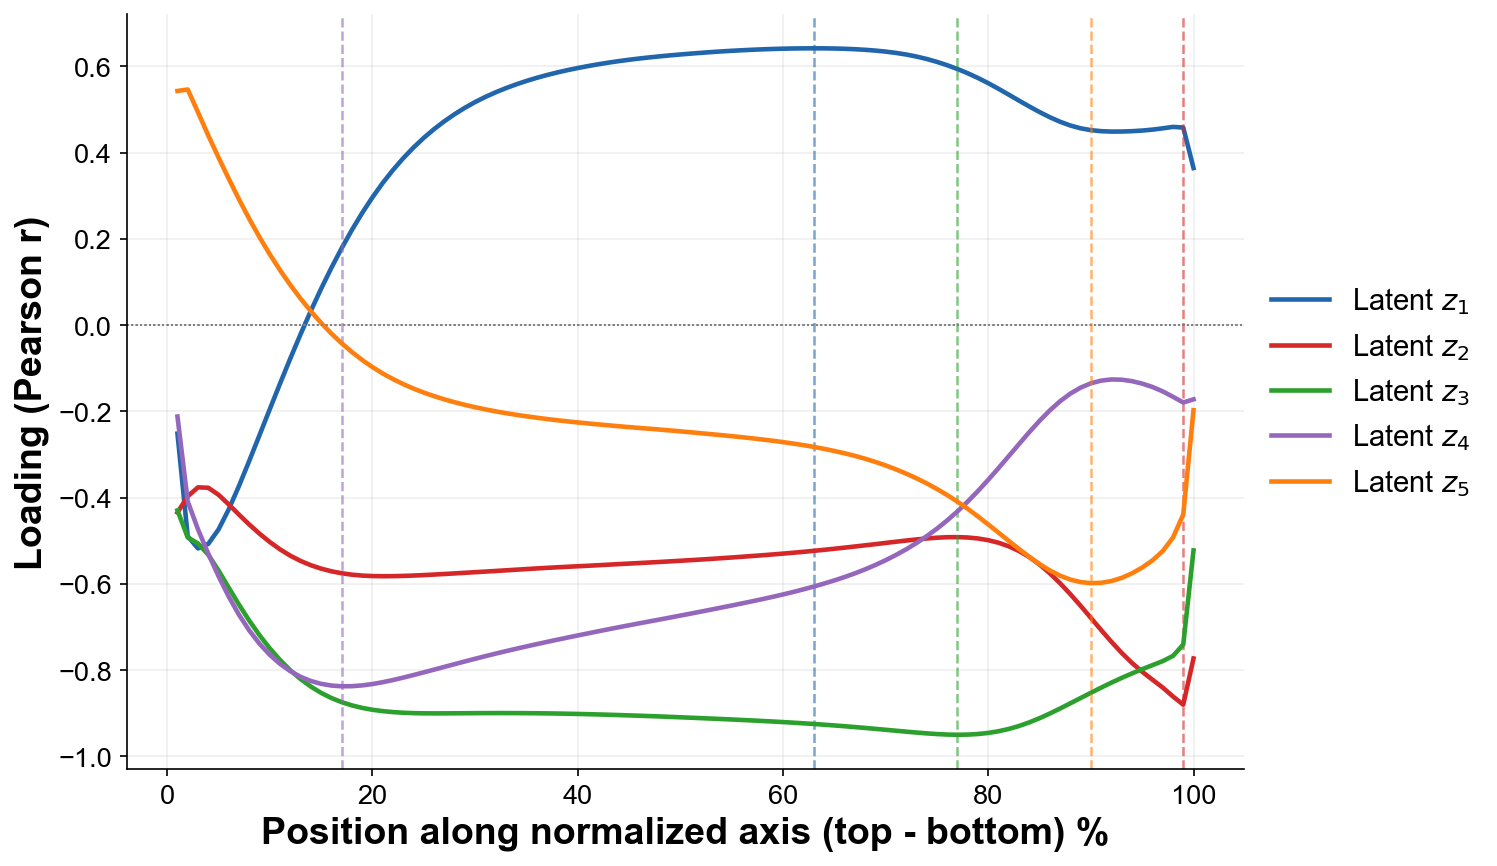

Saved → C:\Users\HP\Desktop\Academic Presentation\seed_project\a_aguo_test_new\vae\latent_load_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")

x_pos = np.arange(1, n_positions + 1)

for dim_idx in range(n_dims):
    loads = load_matrix[dim_idx]
    color = COLORS[dim_idx]
    
    ax.plot(x_pos, loads, color=color, linewidth=2.2, label=f"Latent $z_{{{dim_idx + 1}}}$")
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
    
    max_pos = int(np.argmax(np.abs(loads))) + 1
    ax.axvline(max_pos, color=color, linestyle="--", linewidth=1.2, alpha=0.6)

ax.set_xlabel("Position along normalized axis (top - bottom) %", fontsize=18, fontweight="bold")
ax.set_ylabel("Loading (Pearson r)", fontsize=18, fontweight="bold")
ax.grid(alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout(rect=[0, 0, 0.85, 1])

out_path = os.path.join(OUT_DIR, "latent_load_curves.png")
fig.savefig(out_path, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {out_path}")